## Random Forest

In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix
)

X_train = pd.read_csv("../data/furtherprocessed/X_train.csv")
y_train = pd.read_csv("../data/furtherprocessed/y_train.csv")

X_test = pd.read_csv("../data/furtherprocessed/X_test.csv")
y_test = pd.read_csv("../data/furtherprocessed/y_test.csv")


In [2]:
# 1) build model
rf = RandomForestClassifier(
    n_estimators=200,
    # Uses all available CPU cores to speed up training.
    random_state=42,
    # Uses all available CPU cores to speed up training.
    n_jobs=-1,
    class_weight="balanced"   # crime data often imbalanced
)

# 2) train
y_train = y_train.values.ravel()

rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [3]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# k-fold cross validation ,k=5
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#coarse search
param_grid = {
    ## Number of trees in the forest. More trees generally improve model stability but increase computation time.
    "n_estimators":[100,200,300],
    
    # Number of trees in the forest. More trees generally improve model stability but increase computation time.
    "max_depth":[None,10,20],
   
    # Minimum number of samples required at a leaf node. Larger values produce smoother decision boundaries and reduce overfitting.
    "min_samples_leaf":[1,2,4],
   
    # Number of features considered at each split. Introduces randomness and reduces correlation between trees.
    "max_features":["sqrt","log2"],
    
    # Automatically adjusts class weights inversely proportional to class frequencies to handle class imbalance.
    "class_weight":["balanced"]
}

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=cv,
    scoring=scoring,
    refit="roc_auc",   
    n_jobs=-1,
    # Displays progress information during model training.
    verbose=1
)

grid.fit(X_train,y_train)

print("Best Parameters (coarse search):")
print(grid.best_params_)

print("\nBest CV Score (coarse search):")
print(grid.best_score_)

Fitting 5 folds for each of 54 candidates, totalling 270 fits
{'class_weight': 'balanced', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 300}
0.9701186708860761


In [4]:
#fine search
param_grid_fine = {
    "n_estimators": [250, 300, 350, 400],
    "max_depth": [8, 10, 12, 14],
    "max_features": ["sqrt"],
    "min_samples_leaf": [1, 2, 3],
    "class_weight": ["balanced"]
}

grid_fine = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid_fine,
    scoring=scoring,
    refit="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_fine.fit(X_train, y_train)

print("Best Parameters (Fine Search):")
print(grid_fine.best_params_)

print("\nBest CV Score (Fine Search):")
print(grid_fine.best_score_)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best Parameters (Fine Search):
{'class_weight': 'balanced', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 350}

Best CV Score (Fine Search):
0.9712771247739601


In [6]:
# parameter combinations and their corresponding scores.
results = pd.DataFrame(grid_fine.cv_results_)

cols = [
    "param_n_estimators",
    "param_max_depth",
    "param_max_features",
    "param_min_samples_leaf",
    "mean_test_accuracy",
    "mean_test_precision",
    "mean_test_recall",
    "mean_test_f1",
    "mean_test_roc_auc",
    "rank_test_roc_auc"
]

top_results = results[cols].sort_values("mean_test_roc_auc", ascending=False)

top_results.head(10)

,param_n_estimators,param_max_depth,param_max_features,param_min_samples_leaf,mean_test_accuracy,mean_test_precision,mean_test_recall,mean_test_f1,mean_test_roc_auc,rank_test_roc_auc
14,350,10,sqrt,1,0.935029,0.902359,0.842857,0.869890,0.971277,1
26,350,12,sqrt,1,0.940585,0.917891,0.850000,0.881075,0.971101,2
15,400,10,sqrt,1,0.935029,0.898132,0.850000,0.870961,0.971009,3
27,400,12,sqrt,1,0.938733,0.917224,0.842857,0.876721,0.970743,4
12,250,10,sqrt,1,0.935047,0.904045,0.842857,0.869938,0.970656,5
38,350,14,sqrt,1,0.942437,0.923256,0.850000,0.883651,0.970426,6
1,300,8,sqrt,1,0.923901,0.868143,0.835714,0.850236,0.970306,7
3,400,8,sqrt,1,0.925753,0.869433,0.842857,0.854211,0.970216,8
13,300,10,sqrt,1,0.936899,0.910659,0.842857,0.873184,0.970119,9
39,400,14,sqrt,1,0.940585,0.922971,0.842857,0.879746,0.970111,10


In [7]:
# predict
best_rf = grid_fine.best_estimator_
y_pred = best_rf.predict(X_test)
y_prob = best_rf.predict_proba(X_test)[:, 1]   # calculate probability for binary classification

# evaluate
type(y_test)
y_test = y_test.values.ravel()

print("Test Set Results:")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}")

Test Set Results:
Accuracy : 0.9481
Precision: 1.0000
Recall   : 0.8000
F1-score : 0.8889
ROC-AUC  : 0.9904


In [9]:
#feature importance analysis
importance = pd.Series(
    best_rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importance.head(15))

theft_ratio                 0.118504
battery_ratio               0.109440
lat_mean                    0.096679
commercial_ratio            0.090633
deceptive_practice_ratio    0.079394
other_ratio                 0.078380
criminal_damage_ratio       0.061704
other_crime_ratio           0.059933
residential_ratio           0.058303
public_ratio                0.051808
lon_mean                    0.050823
assault_ratio               0.029130
district_2                  0.018768
district_6                  0.017230
district_9                  0.012581
dtype: float64


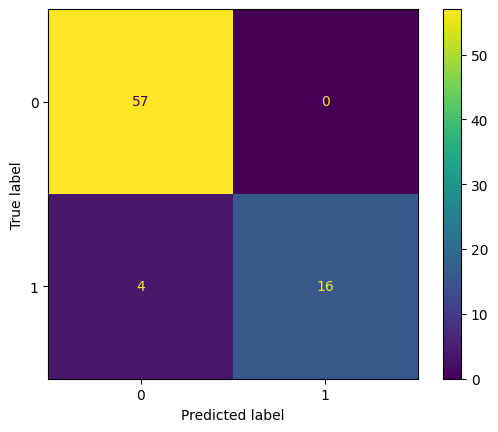

In [10]:
#ConfusionMatrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

In [58]:
#feature ablation experiment by removing crime_count_last3y
X_train_no_count = X_train.drop(columns=["crime_count_last3y"])
X_test_no_count = X_test.drop(columns=["crime_count_last3y"])

best_rf2 = grid_fine.best_estimator_
best_rf2.fit(X_train_no_count, y_train)

y_pred_no_count = best_rf2.predict(X_test_no_count)
y_prob_no_count = best_rf2.predict_proba(X_test_no_count)[:,1]

print("Test Set Results:")
print(f"Accuracy : {accuracy_score(y_test, y_pred_no_count):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_no_count):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_no_count):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred_no_count):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_no_count):.4f}")

Test Set Results:
Accuracy : 0.9221
Precision: 0.8500
Recall   : 0.8500
F1-score : 0.8500
ROC-AUC  : 0.9833


In [61]:
#feature importance analysis
importance = pd.Series(
    best_rf2.feature_importances_,
    index=X_train_no_count.columns
).sort_values(ascending=False)

print(importance.head(15))

battery_ratio               0.124010
theft_ratio                 0.116866
commercial_ratio            0.104666
lat_mean                    0.089894
other_ratio                 0.080760
deceptive_practice_ratio    0.078224
other_crime_ratio           0.063100
residential_ratio           0.059016
lon_mean                    0.056192
public_ratio                0.055663
criminal_damage_ratio       0.054009
assault_ratio               0.029812
district_4                  0.012701
district_6                  0.011727
district_2                  0.011368
dtype: float64


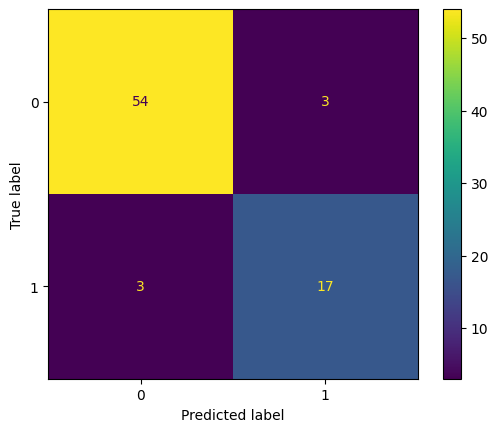

In [60]:
#ConfusionMatrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_no_count)
plt.show()